In [ ]:
# Data handling
import pandas as pd
import numpy as np
import io

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Show the first 5 rows
print("First 5 rows:")
df.head()

Saving heart.csv to heart.csv
First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Check shape
print("Dataset Shape:", df.shape)

# Check data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (303, 14)

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# If there are missing values, we fill them with the column median
df.fillna(df.median(), inplace=True)

print("\nAfter handling missing values:")
print(df.isnull().sum().sum(), "missing values remaining")

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

After handling missing values:
0 missing values remaining


In [ ]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


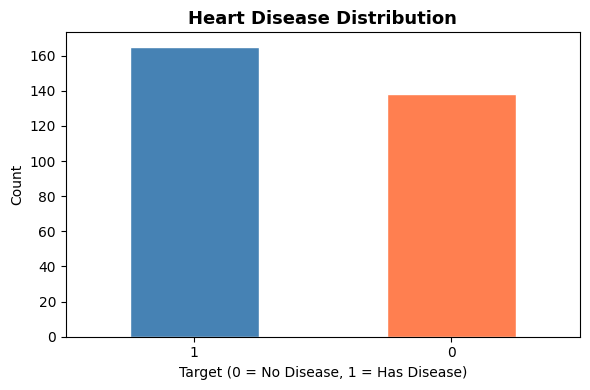

Target Value Counts:
target
1    165
0    138
Name: count, dtype: int64


In [ ]:
# ---- Target Distribution ----
# How many people have heart disease vs not?

plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white')
plt.title('Heart Disease Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Target (0 = No Disease, 1 = Has Disease)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Target Value Counts:")
print(df['target'].value_counts())

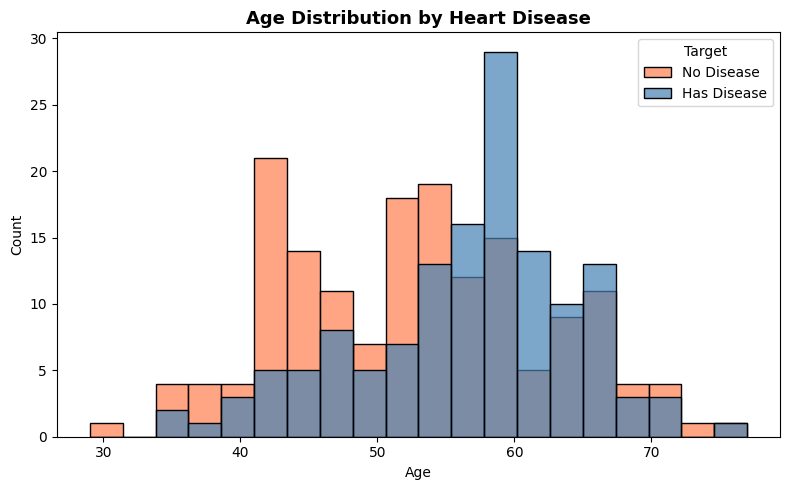

In [ ]:
# ---- Age Distribution by Target ----

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='target', bins=20, palette=['steelblue', 'coral'], alpha=0.7)
plt.title('Age Distribution by Heart Disease', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease', 'Has Disease'])
plt.tight_layout()
plt.show()


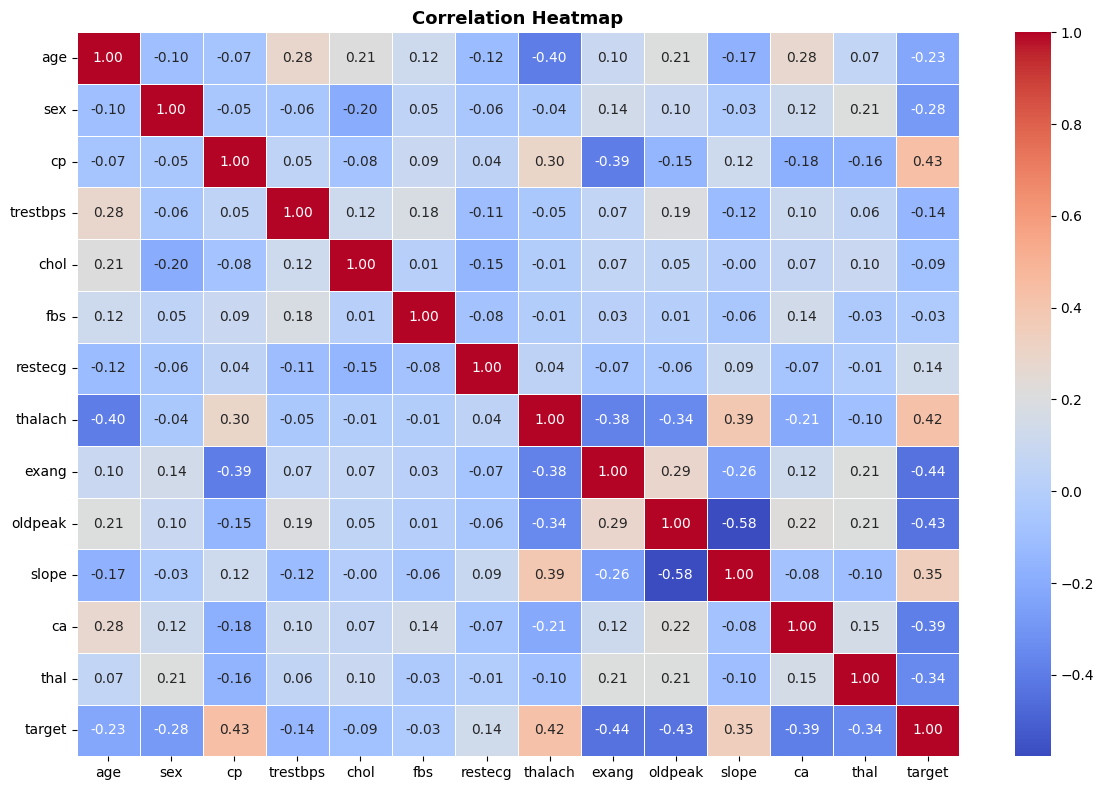

In [ ]:
# ---- Correlation Heatmap ----
# Shows how strongly each feature is related to others

plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=True,          # show numbers
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # color scheme
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)   # all columns except target
y = df['target']                 # only the target column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [ ]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test data
    random_state=42      # for reproducibility
)

print("Training set size:", X_train.shape[0], "samples")
print("Testing set size: ", X_test.shape[0], "samples")

Training set size: 242 samples
Testing set size:  61 samples


In [ ]:
# Feature Scaling: brings all features to the same range
# This helps Logistic Regression perform better
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit on training data
X_test = scaler.transform(X_test)         # apply same scale to test data

print("Features scaled successfully!")

Features scaled successfully!


In [ ]:
# Create and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 85.25%


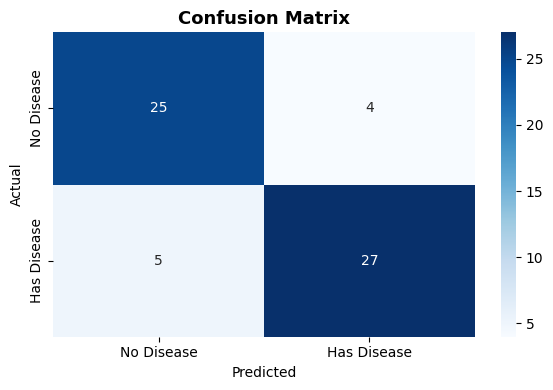

How to read:
Top-left: Correctly predicted No Disease (True Negatives)
Top-right: Incorrectly predicted Has Disease (False Positives)
Bottom-left: Incorrectly predicted No Disease (False Negatives)
Bottom-right: Correctly predicted Has Disease (True Positives)


In [ ]:
# ---- Confusion Matrix ----
# Shows correct and incorrect predictions

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Has Disease'],
    yticklabels=['No Disease', 'Has Disease']
)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("How to read:")
print("Top-left: Correctly predicted No Disease (True Negatives)")
print("Top-right: Incorrectly predicted Has Disease (False Positives)")
print("Bottom-left: Incorrectly predicted No Disease (False Negatives)")
print("Bottom-right: Correctly predicted Has Disease (True Positives)")

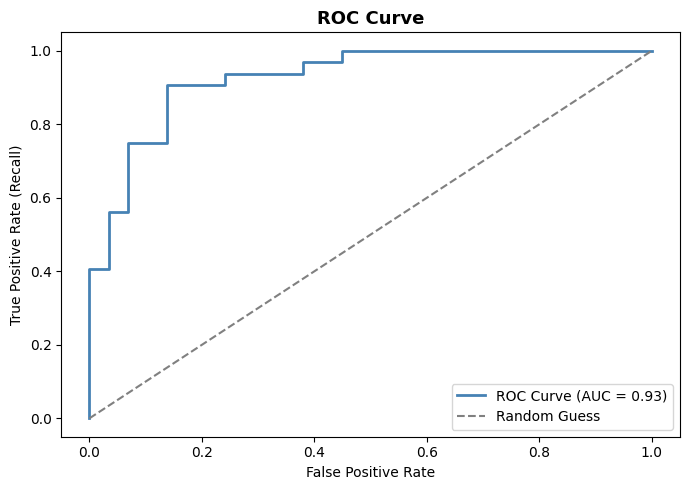

AUC Score: 0.93


In [ ]:
# ---- ROC Curve ----
# Shows model performance at different thresholds

y_prob = model.predict_proba(X_test)[:, 1]   # probability of class 1
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.2f}")

In [ ]:
# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Has Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.86      0.85        29
 Has Disease       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



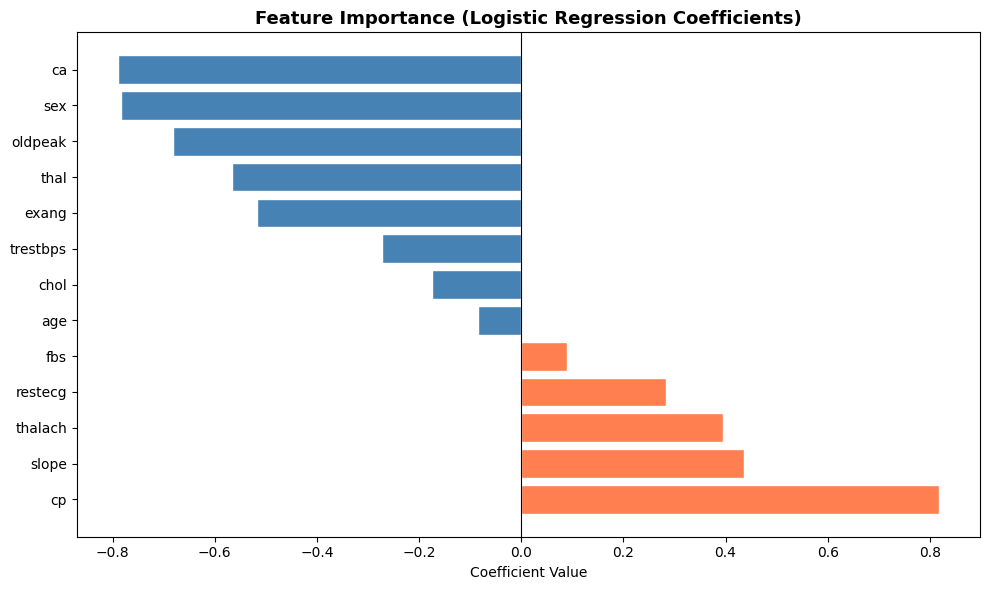

Positive values = increases risk of heart disease
Negative values = decreases risk of heart disease


In [ ]:
# Get feature coefficients from Logistic Regression
feature_names = df.drop('target', axis=1).columns
coefficients = model.coef_[0]

# Create a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in importance_df['Coefficient']]
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, edgecolor='white')
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Positive values = increases risk of heart disease")
print("Negative values = decreases risk of heart disease")